# Multi-Element DG Advection with Periodic Boundary Conditions

This notebook is a fresh implementation of multi-element simplex-DG advection on a square periodic domain.

## Objectives

- Build a square mesh on $[0,1] \times [0,1]$ with triangular elements.
- Construct standard DG connectivity, then overwrite boundary `vmapP` entries to enforce periodic topology.
- Remove boundary ODE and exact-stage boundary injection completely.
- Track $L_2$ and $L_\infty$ errors over time for multiple mesh resolutions.

## PDE and Exact Solution

$$\frac{\partial q}{\partial t} + \mathbf{V}\cdot\nabla q = 0, \quad \mathbf{V}=(1,1).$$

Exact solution (periodic on $[0,1]^2$):
$$q_{\text{exact}}(x,y,t)=\sin\left(2\pi(x+y-2t)\right).$$

In [1]:
# ============================================================================
# CELL 1: Imports and Global Configuration
# ============================================================================

from __future__ import annotations

from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


def _resolve_project_root() -> Path:
    """Resolve project root robustly for notebook execution from different working directories."""
    cwd = Path.cwd().resolve()
    if (cwd / "src").exists():
        return cwd
    if cwd.name == "experimental" and (cwd.parents[1] / "src").exists():
        return cwd.parents[1]
    for parent in cwd.parents:
        if (parent / "src").exists():
            return parent
    raise FileNotFoundError("Cannot locate project root containing src/.")


project_root = _resolve_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.core.generators import get_reference_data
from src.core.connectivity import build_connectivity
from src.geometry.metrics import compute_geometric_factors_batch
from src.geometry.mappings import rs_to_xy
from src.bases.vandermonde import vandermonde_2d_dubiner, grad_vandermonde_2d_dubiner
from src.reconstruction import build_differentiation_matrices, build_fmask_table1

# DG/Time integration configuration
k = 4
N = k + 1
CFL = 1.0
flux_type = "upwind"  # "upwind", "central", or "LF"
alpha_LF = 1.0

# Reference quadrature nodes and weights
ref_data = get_reference_data("table1", k)
xi_ref = ref_data["xi"]
eta_ref = ref_data["eta"]
weights_ref = ref_data["weights"]
weights_1d = ref_data["weights_1d"]
Np = int(len(xi_ref))

print(f"Project root: {project_root}")
print(f"Polynomial degree k={k}, nodes per element Np={Np}, face nodes nfp={len(weights_1d)}")

# Symbolic single-source definitions
x, y, t = sp.symbols("x y t")
q_expr = sp.sin(2 * np.pi * (x - t))
u_expr = sp.sympify(1)
v_expr = sp.sympify(0)

q_exact_func = sp.lambdify((x, y, t), q_expr, "numpy")
u_func_raw = sp.lambdify((x, y, t), u_expr, "numpy")
v_func_raw = sp.lambdify((x, y, t), v_expr, "numpy")

print(f"Exact solution expression: {q_expr}")

Project root: /Users/user/code/Simplex-DG-solver
Polynomial degree k=4, nodes per element Np=22, face nodes nfp=5
Exact solution expression: -sin(6.28318530717959*t - 6.28318530717959*x)


In [2]:
# ============================================================================
# CELL 2: Square Mesh, Connectivity, and Periodic vmapP Construction
# ============================================================================


def generate_square_mesh(n_div: int) -> tuple[np.ndarray, np.ndarray, int]:
    """Generate a uniform triangular mesh on [0,1]x[0,1].

    The mesh is built from a structured Cartesian grid with (n_div x n_div)
    cells, each split into two CCW-oriented triangles.

    Args:
        n_div: Number of subdivisions per coordinate direction.

    Returns:
        nodes: Vertex coordinates, shape (N_vertices, 2).
        EToV: Element-to-vertex connectivity, shape (K, 3).
        K: Number of triangular elements (= 2 * n_div^2).
    """
    if n_div < 1:
        raise ValueError(f"n_div must be >= 1, got {n_div}")

    grid = np.linspace(0.0, 1.0, n_div + 1)
    Xg, Yg = np.meshgrid(grid, grid, indexing="xy")
    nodes = np.column_stack((Xg.ravel(), Yg.ravel()))

    def node_id(i: int, j: int) -> int:
        return j * (n_div + 1) + i

    triangles: list[list[int]] = []
    for j in range(n_div):
        for i in range(n_div):
            v00 = node_id(i, j)
            v10 = node_id(i + 1, j)
            v01 = node_id(i, j + 1)
            v11 = node_id(i + 1, j + 1)

            # Two CCW triangles per square cell
            triangles.append([v00, v10, v11])
            triangles.append([v00, v11, v01])

    EToV = np.asarray(triangles, dtype=int)
    K = int(EToV.shape[0])

    # Orientation check via signed area (must be strictly positive).
    tri_nodes = nodes[EToV]
    signed_area = 0.5 * (
        (tri_nodes[:, 1, 0] - tri_nodes[:, 0, 0]) * (tri_nodes[:, 2, 1] - tri_nodes[:, 0, 1])
        - (tri_nodes[:, 2, 0] - tri_nodes[:, 0, 0]) * (tri_nodes[:, 1, 1] - tri_nodes[:, 0, 1])
    )
    if np.any(signed_area <= 0.0):
        bad = np.where(signed_area <= 0.0)[0]
        raise ValueError(f"Found non-CCW elements at indices: {bad[:10]}")

    print(f"Square mesh built: n_div={n_div}, vertices={nodes.shape[0]}, elements={K}")
    return nodes, EToV, K


def build_global_index_maps(
    EToV: np.ndarray,
    EToE: np.ndarray,
    EToF: np.ndarray,
    xi_ref: np.ndarray,
    eta_ref: np.ndarray,
    Np: int,
    weights_1d: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Build vmapM/vmapP and boundary mask before periodic overwrite.

    Args:
        EToV, EToE, EToF: Connectivity arrays.
        xi_ref, eta_ref: Reference node coordinates.
        Np: Nodes per element.
        weights_1d: Edge quadrature weights.

    Returns:
        vmapM: Interior trace indices, shape (3*nfp, K).
        vmapP: Exterior trace indices (pre-periodic), shape (3*nfp, K).
        boundary_mask: True where face is currently physical boundary.
        fmask: Local face-node table, shape (nfp, 3).
    """
    K = int(EToV.shape[0])
    nfp = int(len(weights_1d))

    # Keep the same xi/eta -> barycentric convention as the reference notebook.
    bary_coords = np.column_stack([
        (-xi_ref - eta_ref) / 2.0,
        (xi_ref + 1.0) / 2.0,
        (eta_ref + 1.0) / 2.0,
    ])
    fmask = build_fmask_table1(bary_coords)

    vmapM = np.zeros((3 * nfp, K), dtype=int)
    vmapP = np.zeros((3 * nfp, K), dtype=int)

    for k_elem in range(K):
        for face in range(3):
            local_nodes = fmask[:, face]
            interior_indices = k_elem * Np + local_nodes
            vmapM[face * nfp:(face + 1) * nfp, k_elem] = interior_indices

            k_neighbor = int(EToE[k_elem, face])
            f_neighbor = int(EToF[k_elem, face])
            if k_neighbor == k_elem:
                vmapP[face * nfp:(face + 1) * nfp, k_elem] = interior_indices
            else:
                neighbor_local_nodes = fmask[:, f_neighbor]
                neighbor_indices = k_neighbor * Np + neighbor_local_nodes
                vmapP[face * nfp:(face + 1) * nfp, k_elem] = neighbor_indices[::-1]

    boundary_mask = vmapM == vmapP
    print(f"vmap built: shape={vmapM.shape}, boundary slots={boundary_mask.sum()}")
    return vmapM, vmapP, boundary_mask, fmask


def _coord_key(x_val: float, y_val: float, tol: float) -> tuple[int, int]:
    """Convert coordinates to a quantized hash key for robust matching."""
    return (int(np.round(x_val / tol)), int(np.round(y_val / tol)))


def apply_periodic_vmapP(
    vmapM: np.ndarray,
    vmapP: np.ndarray,
    boundary_mask: np.ndarray,
    X: np.ndarray,
    Y: np.ndarray,
    tol: float = 1e-12,
) -> np.ndarray:
    """Overwrite boundary `vmapP` entries with periodic counterparts.

    Mapping rules on [0,1]^2:
    - x=0 <-> x=1 (same y)
    - y=0 <-> y=1 (same x)
    - corners map simultaneously in both directions

    Args:
        vmapM: Interior trace indices, shape (3*nfp, K).
        vmapP: Exterior trace indices before periodic overwrite, shape (3*nfp, K).
        boundary_mask: Boolean mask where old vmapP was self-mapped.
        X, Y: Physical nodal coordinates, shape (Np, K).
        tol: Tolerance for boundary and coordinate matching.

    Returns:
        Periodic-overwritten vmapP array with same shape as input.
    """
    vmapP_periodic = vmapP.copy()

    x_flat = X.flatten(order="F")
    y_flat = Y.flatten(order="F")

    boundary_gids = np.unique(vmapM[boundary_mask])
    coord_lookup: dict[tuple[int, int], list[int]] = {}
    for gid in boundary_gids:
        key = _coord_key(float(x_flat[gid]), float(y_flat[gid]), tol)
        coord_lookup.setdefault(key, []).append(int(gid))

    boundary_slots = np.argwhere(boundary_mask)
    replaced = 0

    for slot_row, slot_col in boundary_slots:
        gid_m = int(vmapM[slot_row, slot_col])
        x_m = float(x_flat[gid_m])
        y_m = float(y_flat[gid_m])

        x_target = x_m
        y_target = y_m

        if np.isclose(x_m, 0.0, atol=tol):
            x_target = 1.0
        elif np.isclose(x_m, 1.0, atol=tol):
            x_target = 0.0

        if np.isclose(y_m, 0.0, atol=tol):
            y_target = 1.0
        elif np.isclose(y_m, 1.0, atol=tol):
            y_target = 0.0

        key_target = _coord_key(x_target, y_target, tol)
        candidates = coord_lookup.get(key_target, [])
        if not candidates:
            raise ValueError(
                f"No periodic counterpart found for boundary node (x={x_m:.16e}, y={y_m:.16e}) "
                f"targeting (x={x_target:.16e}, y={y_target:.16e})."
            )

        gid_p = next((cand for cand in candidates if cand != gid_m), candidates[0])
        vmapP_periodic[slot_row, slot_col] = gid_p
        replaced += 1

    remaining_boundary = int(np.sum(vmapM == vmapP_periodic))
    print(f"Periodic overwrite complete: replaced={replaced}, remaining self-maps={remaining_boundary}")
    return vmapP_periodic

In [3]:
# ============================================================================
# CELL 3: DG Operators, Geometry, and RHS (Periodic, No Boundary Injection)
# ============================================================================


def compute_metrics_vectorized(
    nodes: np.ndarray, EToV: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute geometric factors for all elements and a conservative size metric.

    Args:
        nodes: Physical mesh vertices, shape (N_vertices, 2).
        EToV: Element-to-vertex connectivity, shape (K, 3).

    Returns:
        J, rx, ry, sx, sy: Arrays of shape (K,).
        h_min: Elementwise minimum edge length, shape (K,).
    """
    vertices = nodes[EToV]  # (K, 3, 2)
    metrics = compute_geometric_factors_batch(vertices)

    e01 = np.linalg.norm(vertices[:, 1, :] - vertices[:, 0, :], axis=1)
    e12 = np.linalg.norm(vertices[:, 2, :] - vertices[:, 1, :], axis=1)
    e20 = np.linalg.norm(vertices[:, 0, :] - vertices[:, 2, :], axis=1)
    h_min = np.minimum(np.minimum(e01, e12), e20)

    return metrics["J"], metrics["rx"], metrics["ry"], metrics["sx"], metrics["sy"], h_min


def initialize_multi_element_dg(
    nodes: np.ndarray, EToV: np.ndarray, K: int
) -> tuple[
    np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray,
    np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray
]:
    """Initialize reference operators, geometry, and physical nodal coordinates.

    Args:
        nodes: Mesh vertices.
        EToV: Connectivity matrix.
        K: Number of elements.

    Returns:
        D_r_ref, D_s_ref, E, fmask, weights_2d, X, Y,
        J, rx, ry, sx, sy, h_min_array, M_inv_projected
    """
    nfp = int(len(weights_1d))

    V_nodal = vandermonde_2d_dubiner(xi_ref, eta_ref, k)
    Vr, Vs = grad_vandermonde_2d_dubiner(xi_ref, eta_ref, k)
    D_r_ref, D_s_ref = build_differentiation_matrices(V_nodal, Vr, Vs, w=weights_ref)

    W = np.diag(weights_ref)
    M_modal = V_nodal.T @ W @ V_nodal
    M_inv_projected = V_nodal @ np.linalg.inv(M_modal) @ V_nodal.T

    bary_coords = np.column_stack([
        (-xi_ref - eta_ref) / 2.0,
        (xi_ref + 1.0) / 2.0,
        (eta_ref + 1.0) / 2.0,
    ])
    fmask = build_fmask_table1(bary_coords)

    E = np.zeros((3 * nfp, Np))
    for face in range(3):
        for local_i, node_idx in enumerate(fmask[:, face]):
            E[face * nfp + local_i, node_idx] = 1.0

    J, rx, ry, sx, sy, h_min_array = compute_metrics_vectorized(nodes, EToV)

    X = np.zeros((Np, K))
    Y = np.zeros((Np, K))
    for k_elem in range(K):
        v1, v2, v3 = nodes[EToV[k_elem]]
        x_phys, y_phys = rs_to_xy(xi_ref, eta_ref, v1, v2, v3)
        X[:, k_elem] = x_phys
        Y[:, k_elem] = y_phys

    return D_r_ref, D_s_ref, E, fmask, weights_ref, X, Y, J, rx, ry, sx, sy, h_min_array, M_inv_projected


def compute_face_geometry(
    nodes: np.ndarray, EToV: np.ndarray, weights_1d: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute face Jacobians and outward unit normals for each element face.

    Args:
        nodes: Mesh vertices.
        EToV: Connectivity matrix.
        weights_1d: 1D quadrature weights on each face.

    Returns:
        nx_expanded, ny_expanded, J_face_expanded with shape (3*nfp, K).
    """
    K = int(EToV.shape[0])
    nfp = int(len(weights_1d))

    J_face = np.zeros((3, K))
    nx_array = np.zeros((3, K))
    ny_array = np.zeros((3, K))

    for k_elem in range(K):
        v1, v2, v3 = nodes[EToV[k_elem]]
        edges = [v2 - v1, v3 - v2, v1 - v3]
        for face in range(3):
            dx, dy = edges[face]
            length = np.hypot(dx, dy)
            J_face[face, k_elem] = length
            nx_array[face, k_elem] = dy / length
            ny_array[face, k_elem] = -dx / length

    nx_expanded = np.repeat(nx_array, nfp, axis=0)
    ny_expanded = np.repeat(ny_array, nfp, axis=0)
    J_face_expanded = np.repeat(J_face, nfp, axis=0)
    return nx_expanded, ny_expanded, J_face_expanded


def exact_solution_multi(X: np.ndarray, Y: np.ndarray, t_val: float) -> np.ndarray:
    """Evaluate exact scalar field on all element nodes."""
    return q_exact_func(X, Y, t_val)


def velocity_field_multi(X: np.ndarray, Y: np.ndarray, t_val: float) -> tuple[np.ndarray, np.ndarray]:
    """Evaluate velocity components and broadcast constants to array shape."""
    u_arr = np.broadcast_to(u_func_raw(X, Y, t_val), X.shape)
    v_arr = np.broadcast_to(v_func_raw(X, Y, t_val), X.shape)
    return u_arr, v_arr


def compute_rhs_vectorized(
    Q: np.ndarray,
    X: np.ndarray,
    Y: np.ndarray,
    D_r_ref: np.ndarray,
    D_s_ref: np.ndarray,
    E: np.ndarray,
    rx: np.ndarray,
    ry: np.ndarray,
    sx: np.ndarray,
    sy: np.ndarray,
    vmapM: np.ndarray,
    vmapP: np.ndarray,
    weights_2d: np.ndarray,
    J: np.ndarray,
    weights_1d: np.ndarray,
    nx_expanded: np.ndarray,
    ny_expanded: np.ndarray,
    J_face_expanded: np.ndarray,
    M_inv_projected: np.ndarray,
    flux_type: str = "upwind",
    alpha_lf: float = 1.0,
) -> np.ndarray:
    """Compute DG semi-discrete RHS with periodic traces only.

    This routine intentionally has no boundary ODE and no exact boundary injection.
    Periodicity is handled entirely by the pre-overwritten `vmapP`.

    Args:
        Q: State array, shape (1, Np, K).
        X, Y: Physical coordinates, shape (Np, K).
        D_r_ref, D_s_ref: Reference differentiation matrices.
        E: Face extraction matrix.
        rx, ry, sx, sy, J: Geometric factors, shape (K,).
        vmapM, vmapP: Trace maps, shape (3*nfp, K).
        weights_2d: Nodal quadrature weights, shape (Np,).
        weights_1d: Face quadrature weights, shape (nfp,).
        nx_expanded, ny_expanded, J_face_expanded: Face geometry arrays.
        M_inv_projected: Inverse mass projection matrix, shape (Np, Np).
        flux_type: Numerical flux choice.
        alpha_lf: Dissipation coefficient for LF/upwind form.

    Returns:
        RHS with shape (1, Np, K).
    """
    q = Q[0]  # (Np, K)

    u_arr, v_arr = velocity_field_multi(X, Y, 0.0)

    # Reference derivatives
    dq_dr = D_r_ref @ q  # (Np, K) via broadcasting
    dq_ds = D_s_ref @ q  # (Np, K)

    # Physical derivatives with broadcasting
    dq_dx = rx[np.newaxis, :] * dq_dr + sx[np.newaxis, :] * dq_ds  # (Np, K)
    dq_dy = ry[np.newaxis, :] * dq_dr + sy[np.newaxis, :] * dq_ds  # (Np, K)

    # Split-Form volume term (vectorized)
    duq_dr = D_r_ref @ (u_arr * q)  # (Np, K)
    duq_ds = D_s_ref @ (u_arr * q)  # (Np, K)
    dvq_dr = D_r_ref @ (v_arr * q)  # (Np, K)
    dvq_ds = D_s_ref @ (v_arr * q)  # (Np, K)

    # Apply chain rule to get term1 = D_x(u*q) + D_y(v*q)
    term1_x = rx[np.newaxis, :] * duq_dr + sx[np.newaxis, :] * duq_ds  # (Np, K)
    term1_y = ry[np.newaxis, :] * dvq_dr + sy[np.newaxis, :] * dvq_ds  # (Np, K)
    term1 = term1_x + term1_y  # (Np, K)

    # term2 = u*(D_x q) + v*(D_y q)
    term2 = u_arr * dq_dx + v_arr * dq_dy  # (Np, K)

    # term3 = (D_x u + D_y v)*q
    du_dx = rx[np.newaxis, :] * (D_r_ref @ u_arr) + sx[np.newaxis, :] * (D_s_ref @ u_arr)  # (Np, K)
    dv_dy = ry[np.newaxis, :] * (D_r_ref @ v_arr) + sy[np.newaxis, :] * (D_s_ref @ v_arr)  # (Np, K)
    term3 = (du_dx + dv_dy) * q  # (Np, K)

    # Combine volume term (all terms are (Np, K))
    volume_term = -0.5 * (term1 + term2 + term3)  # (Np, K)

    q_flat = q.flatten(order="F")
    q_M = q_flat[vmapM]
    q_P = q_flat[vmapP]

    u_boundary = u_arr.flatten(order="F")[vmapM]
    v_boundary = v_arr.flatten(order="F")[vmapM]
    v_normal = nx_expanded * u_boundary + ny_expanded * v_boundary

    if flux_type == "central":
        C_val = np.zeros_like(v_normal)
    elif flux_type == "upwind":
        C_val = alpha_lf * np.abs(v_normal)
    elif flux_type == "LF":
        C_val = alpha_lf * np.sqrt(u_boundary ** 2 + v_boundary ** 2)
    else:
        raise ValueError(f"Unknown flux_type={flux_type}")

    penalty_factor = 0.5 * (v_normal - C_val)
    flux_penalty = penalty_factor * (q_M - q_P)

    face_w = np.tile(weights_1d, 3)
    scaled_penalty = flux_penalty * face_w[:, np.newaxis] * J_face_expanded

    surface_integral = E.T @ scaled_penalty
    _ = 1.0 / weights_2d  # explicit placeholder to keep strict mass-lumping notation visible
    surface_term = (0.5 / J[np.newaxis, :]) * (M_inv_projected @ surface_integral)

    rhs_q = volume_term + surface_term
    return rhs_q[np.newaxis, :, :]

In [4]:
# ============================================================================
# CELL 4: LSRK54 Time Integrator and Error Tracking (Periodic)
# ============================================================================

A_RK = np.array([
    0.0,
    -567301805773.0 / 1357537059087.0,
    -2404267990393.0 / 2016746695238.0,
    -3550918686646.0 / 2091501179385.0,
    -1275806237668.0 / 842570457699.0,
])
B_RK = np.array([
    1432997174477.0 / 9575080441755.0,
    5161836677717.0 / 13612068292357.0,
    1720146321549.0 / 2090206949498.0,
    3134564353537.0 / 4481467310338.0,
    2277821191437.0 / 14882151754819.0,
])
C_RK = np.array([0.0, 0.1496590219993, 0.3704009573644, 0.6222557631345, 0.9582818314695])


def run_periodic_time_error_tracking(
    n_div: int = 8,
    t_final: float = 2.0,
    CFL: float = 1.0,
    flux_type: str = "upwind",
    alpha_lf: float = 1.0,
) -> dict[str, np.ndarray | float | int]:
    """Run periodic multi-element DG advection and track temporal errors.

    Args:
        n_div: Square mesh subdivisions in each axis.
        t_final: Final integration time.
        CFL: CFL coefficient for global time step.
        flux_type: Numerical flux type in RHS.
        alpha_lf: LF/upwind dissipation scaling.

    Returns:
        Dictionary with time/error histories and run metadata.
    """
    print("\n" + "=" * 78)
    print(f"Periodic DG run: n_div={n_div}, t_final={t_final}, CFL={CFL}")
    print("=" * 78)

    nodes, EToV, K = generate_square_mesh(n_div)
    EToE, EToF = build_connectivity(EToV)

    vmapM, vmapP, boundary_mask, _ = build_global_index_maps(EToV, EToE, EToF, xi_ref, eta_ref, Np, weights_1d)

    (
        D_r_ref,
        D_s_ref,
        E,
        _,
        weights_2d,
        X,
        Y,
        J,
        rx,
        ry,
        sx,
        sy,
        h_min_array,
        M_inv_projected,
    ) = initialize_multi_element_dg(nodes, EToV, K)

    vmapP_periodic = apply_periodic_vmapP(vmapM, vmapP, boundary_mask, X, Y, tol=1e-12)
    remaining_self_maps = int(np.sum(vmapM == vmapP_periodic))
    if remaining_self_maps != 0:
        raise RuntimeError(f"Periodic mapping incomplete: remaining self maps = {remaining_self_maps}")

    nx_expanded, ny_expanded, J_face_expanded = compute_face_geometry(nodes, EToV, weights_1d)

    q_init = exact_solution_multi(X, Y, t_val=0.0)
    Q = q_init[np.newaxis, :, :]

    M_diag = weights_2d[:, np.newaxis] * J[np.newaxis, :]

    u_field, v_field = velocity_field_multi(X, Y, 0.0)
    V_max = float(np.max(np.sqrt(u_field ** 2 + v_field ** 2)))
    dt_global = CFL * float(np.min(h_min_array)) / (V_max * N ** 2)
    print(f"Global dt = {dt_global:.6e}")

    time_history: list[float] = []
    l2_history: list[float] = []
    linf_history: list[float] = []

    t_now = 0.0
    tol_time = 1e-12
    du = np.zeros_like(Q)
    step_count = 0

    while t_now < t_final - tol_time:
        current_dt = min(dt_global, t_final - t_now)
        du.fill(0.0)

        for stage in range(5):
            _ = t_now + C_RK[stage] * current_dt
            R_Q = compute_rhs_vectorized(
                Q=Q,
                X=X,
                Y=Y,
                D_r_ref=D_r_ref,
                D_s_ref=D_s_ref,
                E=E,
                rx=rx,
                ry=ry,
                sx=sx,
                sy=sy,
                vmapM=vmapM,
                vmapP=vmapP_periodic,
                weights_2d=weights_2d,
                J=J,
                weights_1d=weights_1d,
                nx_expanded=nx_expanded,
                ny_expanded=ny_expanded,
                J_face_expanded=J_face_expanded,
                M_inv_projected=M_inv_projected,
                flux_type=flux_type,
                alpha_lf=alpha_lf,
            )

            du = A_RK[stage] * du + current_dt * R_Q
            Q = Q + B_RK[stage] * du

        t_now += current_dt
        step_count += 1

        Q_exact = exact_solution_multi(X, Y, t_now)[np.newaxis, :, :]
        error_field = (Q - Q_exact)[0]

        l2_error = float(np.sqrt(np.sum(error_field ** 2 * M_diag)))
        linf_error = float(np.max(np.abs(error_field)))

        time_history.append(float(t_now))
        l2_history.append(l2_error)
        linf_history.append(linf_error)

        if step_count % 100 == 0:
            print(f"  step={step_count:6d} t={t_now:.6f}/{t_final:.6f} L2={l2_error:.4e}")

    print(f"Completed: steps={step_count}, final_time={t_now:.6f}, final_L2={l2_history[-1]:.4e}")

    return {
        "time": np.array(time_history),
        "l2": np.array(l2_history),
        "linf": np.array(linf_history),
        "dt": float(dt_global),
        "steps": int(step_count),
        "K": int(K),
        "n_div": int(n_div),
    }

In [5]:
# ============================================================================
# CELL 6: Multi-mesh batch runs
# ============================================================================

n_div_list = [4, 8, 16]
t_final_sim = 5.0
CFL_sim = 0.1

simulation_results: dict[int, dict[str, np.ndarray | float | int]] = {}
for n_div_val in n_div_list:
    print(f"\nStarting periodic simulation for n_div={n_div_val}")
    simulation_results[n_div_val] = run_periodic_time_error_tracking(
        n_div=n_div_val,
        t_final=t_final_sim,
        CFL=CFL_sim,
        flux_type=flux_type,
        alpha_lf=alpha_LF,
    )

print("\nAll periodic simulations completed.")


Starting periodic simulation for n_div=4

Periodic DG run: n_div=4, t_final=5.0, CFL=0.1
Square mesh built: n_div=4, vertices=25, elements=32
vmap built: shape=(15, 32), boundary slots=80
Periodic overwrite complete: replaced=80, remaining self-maps=0
Global dt = 1.000000e-03
  step=   100 t=0.100000/5.000000 L2=1.6895e-04
  step=   200 t=0.200000/5.000000 L2=2.0445e-04
  step=   300 t=0.300000/5.000000 L2=2.3042e-04
  step=   400 t=0.400000/5.000000 L2=2.7536e-04
  step=   500 t=0.500000/5.000000 L2=2.8514e-04
  step=   600 t=0.600000/5.000000 L2=2.9178e-04
  step=   700 t=0.700000/5.000000 L2=2.8723e-04
  step=   800 t=0.800000/5.000000 L2=2.7850e-04
  step=   900 t=0.900000/5.000000 L2=2.8933e-04
  step=  1000 t=1.000000/5.000000 L2=3.1032e-04
  step=  1100 t=1.100000/5.000000 L2=3.5003e-04
  step=  1200 t=1.200000/5.000000 L2=3.9437e-04
  step=  1300 t=1.300000/5.000000 L2=4.3037e-04
  step=  1400 t=1.400000/5.000000 L2=4.5692e-04
  step=  1500 t=1.500000/5.000000 L2=4.6419e-04
  

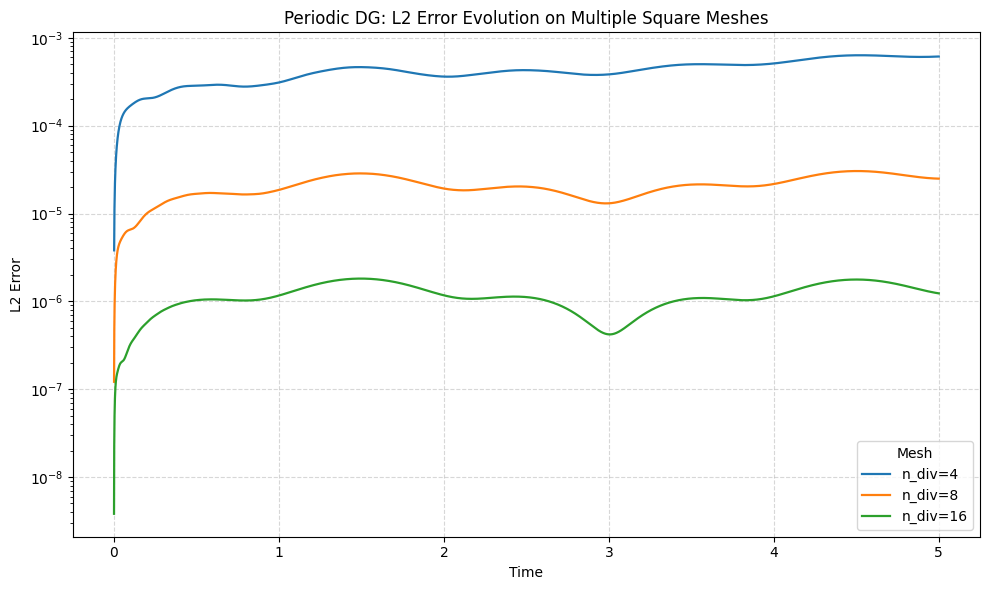

In [6]:
# ============================================================================
# CELL 7: Compare L2 error histories across meshes
# ============================================================================

plt.figure(figsize=(10, 6))
for n_div_val, data in simulation_results.items():
    plt.plot(data["time"], data["l2"], label=f"n_div={n_div_val}", linewidth=1.6)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("L2 Error")
plt.title("Periodic DG: L2 Error Evolution on Multiple Square Meshes")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Mesh", loc="best")
plt.tight_layout()
plt.show()

=== Convergence Results near t = 20.0 ===


,n_div,h,Actual Time,L2 Error,L2 Order,Linf Error,Linf Order
0,4,0.2500,5.000000,6.133e-04,nan,3.802e-03,nan
1,8,0.1250,5.000000,2.495e-05,4.619677,1.781e-04,4.416112
2,16,0.0625,5.000000,1.234e-06,4.337890,8.555e-06,4.379550


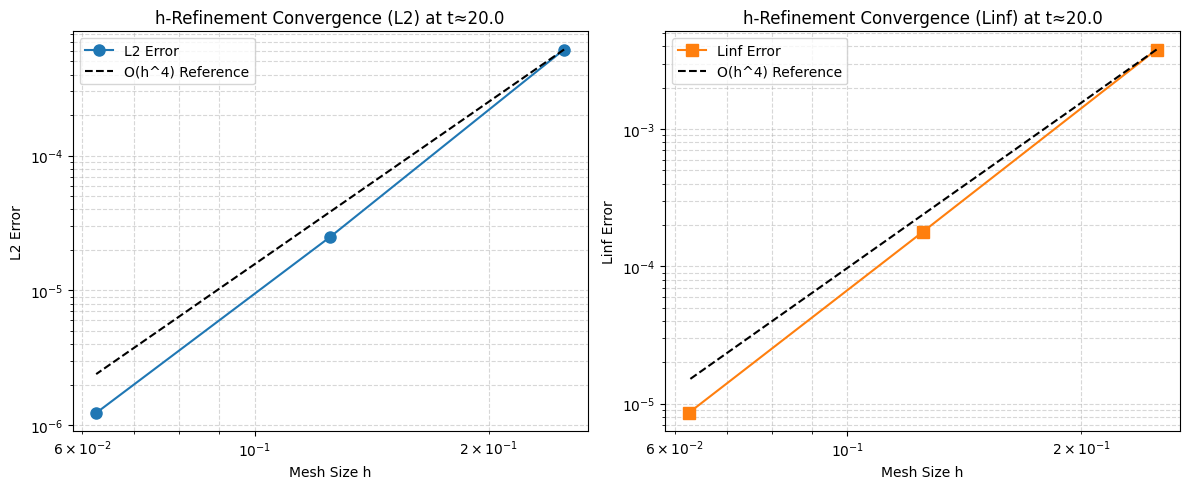

In [7]:
# ============================================================================
# CELL: 任意時間點的收斂階數計算與繪圖 (Convergence at Specific Time)
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 1. 設定目標時間與參數
# ---------------------------------------------------------
target_time = 20.0          # 👈 請在此輸入您想觀察的時間點 (例如 t_final)
expected_order = 4         # 預期收斂階數
domain_length = 1.0        # 物理區域長度 (假設為 [0,1]x[0,1])

# ---------------------------------------------------------
# 2. 擷取最接近 target_time 的數據
# ---------------------------------------------------------
h_values = []
l2_errors = []
linf_errors = []
actual_times = []
n_div_list_sorted = sorted(list(simulation_results.keys()))

for n_div in n_div_list_sorted:
    data = simulation_results[n_div]
    time_array = np.array(data["time"])

    # 找出與 target_time 絕對誤差最小的 index
    nearest_idx = (np.abs(time_array - target_time)).argmin()

    actual_times.append(time_array[nearest_idx])
    h_values.append(domain_length / n_div)
    l2_errors.append(data["l2"][nearest_idx])
    linf_errors.append(data["linf"][nearest_idx])

h_values = np.array(h_values)
l2_errors = np.array(l2_errors)
linf_errors = np.array(linf_errors)

# ---------------------------------------------------------
# 3. 計算收斂階數 (Convergence Rates)
# ---------------------------------------------------------
l2_rates = [np.nan]
linf_rates = [np.nan]

for i in range(1, len(h_values)):
    # Order = ln(E1/E2) / ln(h1/h2)
    rate_l2 = np.log(l2_errors[i-1] / l2_errors[i]) / np.log(h_values[i-1] / h_values[i])
    rate_linf = np.log(linf_errors[i-1] / linf_errors[i]) / np.log(h_values[i-1] / h_values[i])
    l2_rates.append(rate_l2)
    linf_rates.append(rate_linf)

# 建立 DataFrame 以表格呈現
df_convergence = pd.DataFrame({
    "n_div": n_div_list_sorted,
    "h": h_values,
    "Actual Time": actual_times,
    "L2 Error": l2_errors,
    "L2 Order": l2_rates,
    "Linf Error": linf_errors,
    "Linf Order": linf_rates
})

print(f"=== Convergence Results near t = {target_time} ===")
display(df_convergence.style.format({
    "h": "{:.4f}",
    "L2 Error": "{:.3e}",
    "Linf Error": "{:.3e}",
}))
# ---------------------------------------------------------
# 4. 繪製收斂圖 (Log-Log Plot)
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- L2 Error Plot ---
ax1.loglog(h_values, l2_errors, 'o-', label='L2 Error', markersize=8, color='tab:blue')
# 繪製參考線
ref_l2 = l2_errors[0] * (h_values / h_values[0])**expected_order
ax1.loglog(h_values, ref_l2, 'k--', label=f'O(h^{expected_order}) Reference', linewidth=1.5)

ax1.set_xlabel('Mesh Size h')
ax1.set_ylabel('L2 Error')
ax1.set_title(f'h-Refinement Convergence (L2) at t≈{target_time}')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend()

# --- Linf Error Plot ---
ax2.loglog(h_values, linf_errors, 's-', label='Linf Error', markersize=8, color='tab:orange')
# 繪製參考線
ref_linf = linf_errors[0] * (h_values / h_values[0])**expected_order
ax2.loglog(h_values, ref_linf, 'k--', label=f'O(h^{expected_order}) Reference', linewidth=1.5)

ax2.set_xlabel('Mesh Size h')
ax2.set_ylabel('Linf Error')
ax2.set_title(f'h-Refinement Convergence (Linf) at t≈{target_time}')
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()